<a href="https://colab.research.google.com/github/Junaid-Altaf/Ai-object-narrator/blob/main/Compare_All_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Testing google/flan-t5-small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== All Models Comparison ===
                  Model  Financial_Attention  Medical_Attention  Dilution
distilbert-base-uncased             0.876213           0.902536  0.026322
           roberta-base             0.373713           0.419124  0.045411


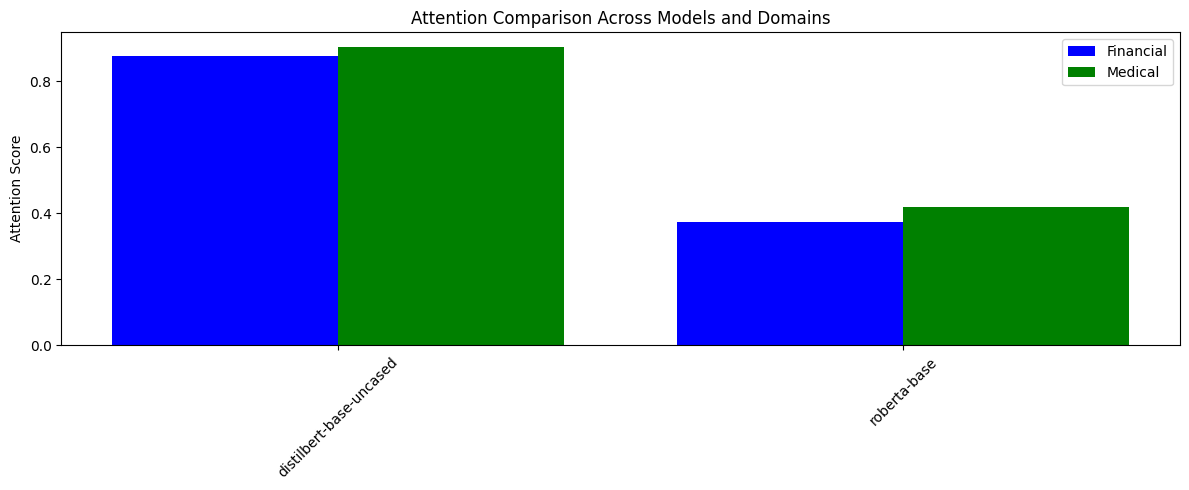

Comparison saved!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Store all results
results = []

models_to_test = [
    "google/flan-t5-small",
    "distilbert-base-uncased",
    "roberta-base",
]

financial_prompt = "Stock market showed strong growth today"
medical_prompt = "Patient diagnosed with severe infection"

from transformers import AutoTokenizer, AutoModel
import torch

for model_name in models_to_test:
    print(f"\nTesting {model_name}...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(
            model_name,
            output_attentions=True
        )

        # Financial
        fin_inputs = tokenizer(
            financial_prompt,
            return_tensors="pt",
            truncation=True
        )
        with torch.no_grad():
            fin_out = model(**fin_inputs)
        fin_att = fin_out.attentions[-1][0].mean(dim=0)[-1]

        # Medical
        med_inputs = tokenizer(
            medical_prompt,
            return_tensors="pt",
            truncation=True
        )
        with torch.no_grad():
            med_out = model(**med_inputs)
        med_att = med_out.attentions[-1][0].mean(dim=0)[-1]

        results.append({
            "Model": model_name.split("/")[-1],
            "Financial_Attention": fin_att.max().item(),
            "Medical_Attention": med_att.max().item(),
            "Dilution": abs(
                fin_att.max().item() -
                med_att.max().item()
            )
        })

    except Exception as e:
        print(f"Error with {model_name}: {e}")

# Show results table
df = pd.DataFrame(results)
print("\n=== All Models Comparison ===")
print(df.to_string(index=False))
df.to_csv("model_comparison.csv", index=False)

# Plot comparison
plt.figure(figsize=(12, 5))
x = range(len(df))
plt.bar(
    [i - 0.2 for i in x],
    df["Financial_Attention"],
    width=0.4,
    label="Financial",
    color="blue"
)
plt.bar(
    [i + 0.2 for i in x],
    df["Medical_Attention"],
    width=0.4,
    label="Medical",
    color="green"
)
plt.xticks(x, df["Model"], rotation=45)
plt.title("Attention Comparison Across Models and Domains")
plt.ylabel("Attention Score")
plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()
print("Comparison saved!")